# Phase 4 — Results Summary

## Project Overview
Analyzed Q1 2026 earnings call transcripts for 20 S&P 500 companies
using FinBERT — a BERT model fine-tuned on financial text.

## Data Pipeline
- Source: SEC EDGAR 8-K filings (official US government database)
- Stock prices: Yahoo Finance via yfinance
- Sentiment model: ProsusAI/FinBERT
- Companies: 20 S&P 500 companies across Tech, Finance, Healthcare, Consumer

## Key Question
Does earnings call sentiment predict stock price movement?

## Answer
Counterintuitively — no. Higher positive sentiment actually 
correlated with worse next-day stock performance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns

# load all results
df_meta = pd.read_csv('data/filings_metadata.csv')
df_sentiment = pd.read_csv('data/sentiment_results.csv')
df_prices = pd.read_csv('data/price_changes.csv')

# merge everything
df = df_meta.merge(df_sentiment, on='ticker').merge(df_prices, on='ticker')
df['sentiment_ratio'] = df['positive'] - df['negative']

# add sector labels
sectors = {
    'AAPL': 'Tech', 'MSFT': 'Tech', 'AMZN': 'Tech',
    'GOOGL': 'Tech', 'META': 'Tech', 'NVDA': 'Tech', 'TSLA': 'Tech',
    'JPM': 'Finance', 'BAC': 'Finance', 'GS': 'Finance',
    'MS': 'Finance', 'WFC': 'Finance', 'V': 'Finance',
    'JNJ': 'Healthcare', 'PFE': 'Healthcare', 
    'UNH': 'Healthcare', 'CVS': 'Healthcare', 'ABT': 'Healthcare',
    'WMT': 'Consumer', 'KO': 'Consumer'
}
df['sector'] = df['ticker'].map(sectors)

print(f"Dataset ready: {len(df)} companies")
print(df[['ticker', 'company', 'sector', 'sentiment_ratio', 
          'change_1d_pct', 'change_1w_pct']].to_string(index=False))

Dataset ready: 20 companies
ticker               company     sector  sentiment_ratio  change_1d_pct  change_1w_pct
  AAPL             Apple Inc       Tech           0.2132           3.24           5.93
  MSFT Microsoft Corporation       Tech          -0.0550          -3.93          -2.47
   JPM        JPMorgan Chase    Finance           0.2467          -1.67           0.60
   JNJ     Johnson & Johnson Healthcare           0.2754          -0.60          -5.81
  AMZN                Amazon       Tech           0.1359           0.77           4.54
 GOOGL              Alphabet       Tech           0.0789           9.96          13.75
   BAC       Bank of America    Finance           0.2760          -1.49          -2.21
   PFE                Pfizer Healthcare           0.0004           0.30          -0.58
     V                  Visa    Finance           0.1518           8.26           4.12
   UNH    UnitedHealth Group Healthcare           0.0265           2.17           6.00
    GS         

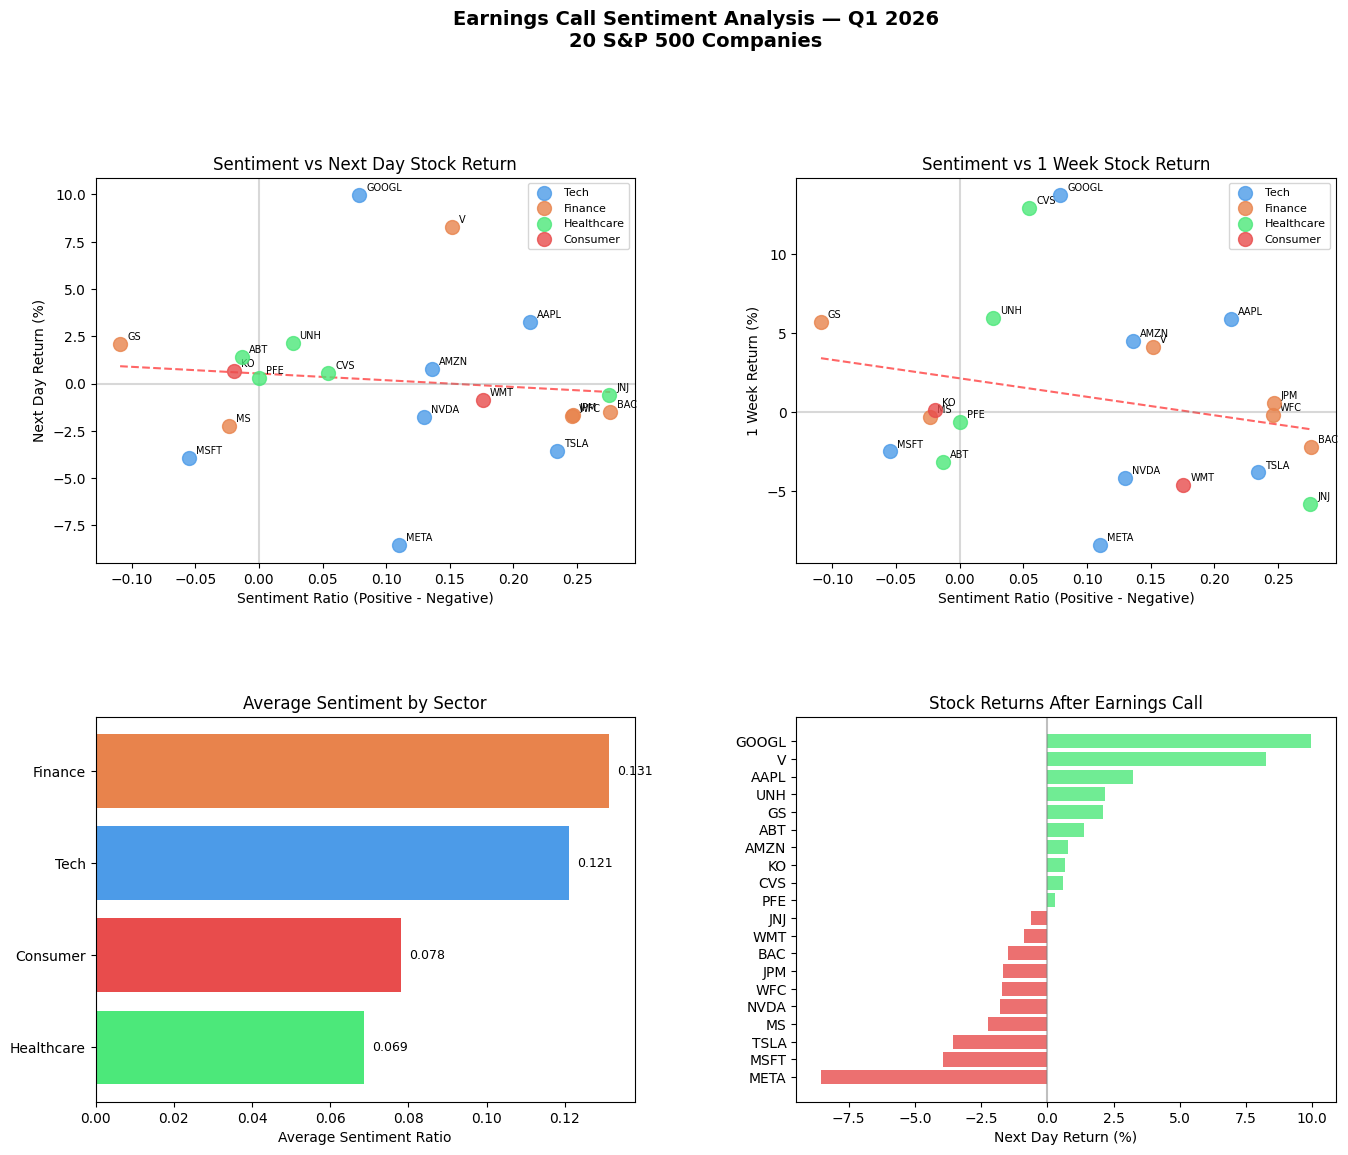

Final results chart saved


In [2]:
fig = plt.figure(figsize=(16, 12))
gs_layout = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# ── Chart 1: Sentiment ratio vs 1 day return ──
ax1 = fig.add_subplot(gs_layout[0, 0])

colors = {'Tech': '#4C9BE8', 'Finance': '#E8834C', 
          'Healthcare': '#4CE87A', 'Consumer': '#E84C4C'}

for sector in df['sector'].unique():
    mask = df['sector'] == sector
    ax1.scatter(
        df[mask]['sentiment_ratio'],
        df[mask]['change_1d_pct'],
        color=colors[sector], label=sector,
        alpha=0.8, s=100, zorder=5
    )

# add ticker labels
for _, row in df.iterrows():
    ax1.annotate(row['ticker'],
                 (row['sentiment_ratio'], row['change_1d_pct']),
                 textcoords="offset points", xytext=(5, 3), fontsize=7)

# trend line
z = np.polyfit(df['sentiment_ratio'], df['change_1d_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['sentiment_ratio'].min(), df['sentiment_ratio'].max(), 100)
ax1.plot(x_line, p(x_line), "r--", alpha=0.6, linewidth=1.5)

ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax1.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax1.set_xlabel('Sentiment Ratio (Positive - Negative)')
ax1.set_ylabel('Next Day Return (%)')
ax1.set_title('Sentiment vs Next Day Stock Return')
ax1.legend(fontsize=8)

# ── Chart 2: Sentiment ratio vs 1 week return ──
ax2 = fig.add_subplot(gs_layout[0, 1])

for sector in df['sector'].unique():
    mask = df['sector'] == sector
    ax2.scatter(
        df[mask]['sentiment_ratio'],
        df[mask]['change_1w_pct'],
        color=colors[sector], label=sector,
        alpha=0.8, s=100, zorder=5
    )

for _, row in df.iterrows():
    ax2.annotate(row['ticker'],
                 (row['sentiment_ratio'], row['change_1w_pct']),
                 textcoords="offset points", xytext=(5, 3), fontsize=7)

z2 = np.polyfit(df['sentiment_ratio'], df['change_1w_pct'], 1)
p2 = np.poly1d(z2)
ax2.plot(x_line, p2(x_line), "r--", alpha=0.6, linewidth=1.5)
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax2.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax2.set_xlabel('Sentiment Ratio (Positive - Negative)')
ax2.set_ylabel('1 Week Return (%)')
ax2.set_title('Sentiment vs 1 Week Stock Return')
ax2.legend(fontsize=8)

# ── Chart 3: Sentiment by sector ──
ax3 = fig.add_subplot(gs_layout[1, 0])

sector_sentiment = df.groupby('sector')['sentiment_ratio'].mean().sort_values()
bars = ax3.barh(sector_sentiment.index, sector_sentiment.values,
                color=[colors[s] for s in sector_sentiment.index])

for bar, val in zip(bars, sector_sentiment.values):
    ax3.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

ax3.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
ax3.set_xlabel('Average Sentiment Ratio')
ax3.set_title('Average Sentiment by Sector')

# ── Chart 4: Top movers vs sentiment ──
ax4 = fig.add_subplot(gs_layout[1, 1])

df_sorted = df.sort_values('change_1d_pct')
bar_colors = ['#E84C4C' if x < 0 else '#4CE87A' 
              for x in df_sorted['change_1d_pct']]

bars = ax4.barh(df_sorted['ticker'], df_sorted['change_1d_pct'],
                color=bar_colors, alpha=0.8)
ax4.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
ax4.set_xlabel('Next Day Return (%)')
ax4.set_title('Stock Returns After Earnings Call')

plt.suptitle('Earnings Call Sentiment Analysis — Q1 2026\n20 S&P 500 Companies',
             fontsize=14, fontweight='bold', y=1.02)

plt.savefig('charts/final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final results chart saved")